# Ultimate (low-frequency) VLISM structure functions

Daily averages of V1 LISM are very K41 monofractal! Certainly suggests not yet at outer scale...

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal
from scipy.stats import linregress


from fbm import FBM

# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

In [2]:
v1_raw = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
v1_res = v1_raw.resample("48s").mean()
v1_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7461001 entries, 2012-08-25 00:00:00 to 2023-12-31 00:00:00
Freq: 48s
Data columns (total 4 columns):
 #   Column  Dtype  
---  ------  -----  
 0   F1      float32
 1   BR      float32
 2   BT      float32
 3   BN      float32
dtypes: float32(4)
memory usage: 170.8 MB


In [3]:
v1_res = v1_raw.resample("1d").mean()
v1_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4146 entries, 2012-08-25 to 2023-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      3969 non-null   float32
 1   BR      3969 non-null   float32
 2   BT      3969 non-null   float32
 3   BN      3969 non-null   float32
dtypes: float32(4)
memory usage: 97.2 KB


In [4]:
v2_raw = pd.read_pickle("../data/interim/voyager/voyager2_lism.pkl")
v2_res = v2_raw.resample("1d").mean()
v2_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1518 entries, 2018-11-05 to 2022-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      1438 non-null   float32
 1   BR      1438 non-null   float32
 2   BT      1438 non-null   float32
 3   BN      1438 non-null   float32
dtypes: float32(4)
memory usage: 35.6 KB


In [5]:
sf_v1 = sf_funcs.compute_sf(
    v1_res[["BR", "BT", "BN"]], np.arange(1, len(v1_res)), [2], False, False, None
)

sf_v2 = sf_funcs.compute_sf(
    v2_res[["BR", "BT", "BN"]], np.arange(1, len(v2_res)), [2], False, False, None
)

Text(0.5, 1.0, 'Second-order Structure Functions')

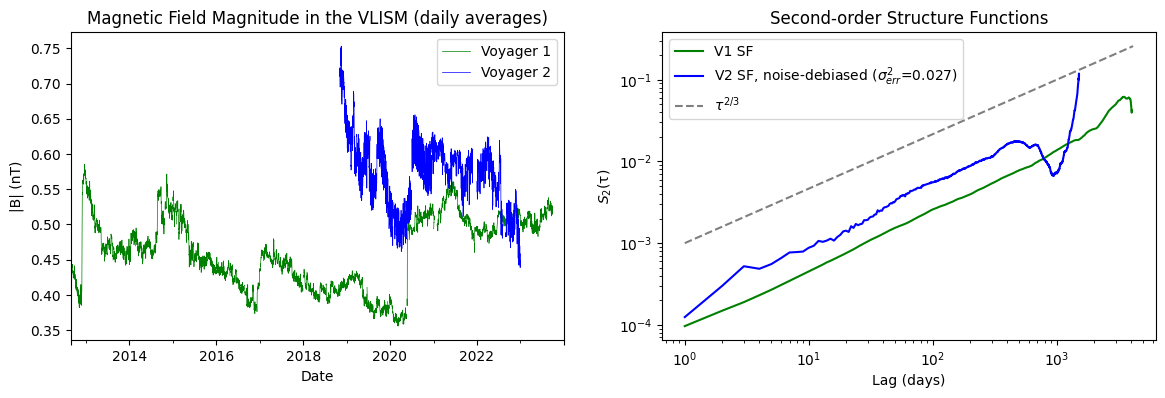

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
v1_res["F1"].plot(ax=ax[0], label="Voyager 1", c="green", lw=0.5)
v2_res["F1"].plot(ax=ax[0], label="Voyager 2", c="blue", lw=0.5)
ax[0].legend()
ax[0].set_ylabel("|B| (nT)")
ax[0].set_xlabel("Date")

ax[1].plot(
    sf_v1.lag,
    sf_v1.sf_2,
    color="green", 
    label="V1 SF"
)

nugget = 0.0015
sigma_err = np.sqrt(nugget/2)

ax[1].plot(sf_v2.lag, sf_v2.sf_2-nugget, color="blue", label=f"V2 SF, noise-debiased ($\sigma^2_{{err}}$={sigma_err:.3f})")

# Plot 2/3 power law
ax[1].plot(
    sf_v1.lag,
    0.001 * np.power(sf_v1.lag, 2 / 3),
    label="$\\tau^{2/3}$",
    color="black",
    linestyle="--",
    alpha=0.5,
)

ax[1].legend()
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("Lag (days)")
ax[1].set_ylabel("$S_2$(τ)")
ax[0].set_title("Magnetic Field Magnitude in the VLISM (daily averages)")
ax[1].set_title(f"Second-order Structure Functions")

In [7]:
0.027**2*2

0.0014579999999999999

Potentially relevant? 

- [Statistical inference of random field auto-correlation structure from multiple sets of incomplete and sparse measurements using Bayesian compressive sampling-based bootstrapping](https://www.sciencedirect.com/science/article/pii/S0888327019300652#s0065)
- [Interpolation uncertainty of atmospheric temperature profiles](https://amt.copernicus.org/articles/13/6445/2020/amt-13-6445-2020.html)